<a href="https://colab.research.google.com/github/ish66726-a11y/finance-prep/blob/main/02_bonds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#債券数学

#2-1 債券の基礎

## 債券とは
- 投資家が国や企業にお金を貸し、利子と元本の返済を受け取る「負債証券」。
- 株式とは異なり、あらかじめ約束されたキャッシュフロー（CF）を受け取る点が特徴。

---

## 債券の2つの基本タイプ

#### 1. ゼロクーポン債（Zero Coupon Bond）
- 利子（クーポン）を支払わず、満期に額面のみを一括で返済する。
- キャッシュフローは満期時の1回だけ。

#### 2. 利付債／クーポン債（Coupon Bond）
- 満期までの各期に一定額のクーポン（利子）を支払い、満期時に額面（元本）も返済する。
- キャッシュフローは「各期のクーポン」＋「満期時のクーポン＋額面」。

---

## 用語の整理

| 用語 | 意味 |
|------|------|
| 額面（Face Value / Par Value） | 満期に返済される元本の金額 |
| クーポン率（Coupon Rate） | 額面に対する年間利子の割合 |
| クーポン（Coupon） | 各期に実際に支払われる利子額（＝額面×クーポン率／年間支払回数） |
| 満期（Maturity） | 元本が返済されるまでの期間 |
| 償還（Redemption） | 満期に額面が返済されること |

---

## キャッシュフロー構造

満期 $N$ 年、年1回クーポン支払いの債券を考える。

- $t=1,2,\dots,N-1$：クーポン $C$ のみ
- $t=N$：クーポン $C$ ＋ 額面 $X$

$$
CF_t =
\begin{cases}
C & (1 \le t < N) \\
C + X & (t = N)
\end{cases}
$$

ゼロクーポン債は $C=0$ の特殊ケースとみなせる（$t=N$ でのみ $X$ を受け取る）。

👉 債券価格・利回りの計算はすべて、この「キャッシュフローの並び」を出発点にする。

👉 以降の2-2（価格付け）、2-3（利回り）は、この構造をどう割り引くか／どう逆算するかの話になる。

---

## Python実装：bond_cashflows

In [ ]:
# ゼロクーポン債の価格を計算する関数
def calculate_zero_coupon_price(principal, maturity, interest_rate):
    r = interest_rate / 100  # %を小数に変換
    return principal / ((1 + r) ** maturity)


# 実行部分
if __name__ == "__main__":
    price = calculate_zero_coupon_price(1000, 2, 4)
    print(f"債券価格 = {price:.2f}円")

債券価格 = 924.56円


In [ ]:
# クーポン債の価格を計算する関数
def calculate_coupon_bond_price(principal, coupon_rate, maturity, interest_rate):
    r = interest_rate / 100      # 市場金利
    c = coupon_rate / 100        # クーポン利率
    coupon = principal * c

    price = 0

    # 各年のクーポンを割引
    for t in range(1, maturity + 1):
        price += coupon / ((1 + r) ** t)

    # 満期時の元本を割引
    price += principal / ((1 + r) ** maturity)

    return price


# ===== 実行部分 =====

price = calculate_coupon_bond_price(1000, 10, 3, 4)
print(f"債券価格 = {price:.2f}円")


債券価格 = 1166.51円


#2-2 価格付け（順問題：r → P）

## 2-1との接続
2-1 で作った「キャッシュフローの並び」に対して、
市場金利 $r$ が分かっているとき、その債券の適正価格 $P$ を求める。

これは「割引率 $r$ から価格 $P$ を求める」という意味で、順問題（$r \rightarrow P$）と呼ぶ。

---

## 価格式：将来キャッシュフローの現在価値

債券価格は、将来受け取るキャッシュフローすべてを現在価値に割り引いた合計として定義される。

$$
P = \sum_{t=1}^{N} \frac{CF_t}{(1+r)^t}
$$

- $P$：債券価格（現在価値）
- $CF_t$：時点 $t$ に受け取るキャッシュフロー（2-1参照）
- $r$：割引に用いる市場金利（1期あたり、ここでは満期まで一定と仮定＝フラットレート）
- $N$：満期までの期数

※ ここでは「金利 $r$ が全期間にわたって一定」という単純化（フラットレート）を置いている。
　実際の市場では満期ごとに異なる金利（イールドカーブ）が存在するが、これは2-7で扱う。

---

## 直感

- 割引率 $r$ が高いほど、将来のお金の「今の価値」は小さくなる → 価格は下がる。
- 割引率 $r$ が低いほど、将来のお金の「今の価値」は大きくなる → 価格は上がる。

この「$r$ と $P$ が逆方向に動く」という関係は、2-4で改めて詳しく扱う。

👉 価格付けは「未来のお金を、金利を使って“今の価値”に変換して足し合わせる」作業である。

---

## Python実装：price_from_yield

#2-3 利回り（逆問題：P → y）

## 2-2との違い：計算の「向き」
- 2-2（価格付け）：市場金利 $r$ が既知 → 適正価格 $P$ を求める（順問題：$r \rightarrow P$）
- 2-3（利回り）：市場で観測された価格 $P$ が既知 → その債券の「真の収益率 $y$」を逆算する（逆問題：$P \rightarrow y$）

---

## 直接利回り（Current Yield）

もっとも単純な利回りの指標。

$$
\text{直接利回り} = \frac{\text{年間クーポン額}}{\text{債券価格}}
$$

- 元本の変動（額面と価格の差）や再投資を考慮しない、簡易的な指標。

---

## 最終利回り（Yield to Maturity, YTM）

- 債券を満期まで保有した場合の「実質的な年率収益率」。
- ファイナンスでいう内部収益率（IRR）と同じ考え方＝「価格と将来CFの現在価値を一致させる割引率」。

$$
P = \sum_{t=1}^{N} \frac{CF_t}{(1+y)^t}
$$

これは2-2の価格式と全く同じ形をしているが、$P$ が既知で $y$ が未知という点が異なる。

言い換えると、YTM は次の非線形方程式 $f(y)=0$ の解として定義される。

$$
f(y) = P - \sum_{t=1}^{N} \frac{CF_t}{(1+y)^t} = 0
$$

この方程式は一般に解析的に解けないため、数値計算（ニュートン法・二分法など）で $y$ を求める。

---

## 直接利回りとYTMの違い

| 項目 | 直接利回り | YTM |
|------|-----------|-----|
| 計算対象 | 年間クーポンのみ | すべてのキャッシュフロー |
| 元本の変動 | 考慮しない | 考慮する |
| 再投資の仮定 | なし | あり（クーポンを同じ利回りで再投資） |
| 求め方 | 単純な割り算 | 非線形方程式を数値的に解く |

👉 実務・理論分析で重要なのは YTM。直接利回りはあくまで簡易的な目安。

---

## Python実装：ytm_from_price（ニュートン法／二分法）

In [ ]:
def ytm_from_price(price, times, cashflows, frequency=1,
                    x0=0.05, tol=1e-8, max_iter=100):
    """
    債券価格 price から最終利回り（YTM）を逆算する（逆問題：P → y）

    価格式 P = Σ CF_t / (1+y)^t を満たす y を、
    まずニュートン法で探索し、収束しない場合は二分法にフォールバックする。

    price      : 市場価格（既知）
    times      : 各キャッシュフローの発生時点（年）
    cashflows  : 各時点のキャッシュフロー
    frequency  : 年間の複利回数
    x0         : ニュートン法の初期値
    """

    def f(y):
        # f(y) = 0 を満たす y がYTM
        return price_from_yield(times, cashflows, y, frequency) - price

    # ----- ニュートン法 -----
    y = x0
    for _ in range(max_iter):
        h = 1e-6
        f_y = f(y)
        f_prime = (f(y + h) - f(y - h)) / (2 * h)  # 数値微分（中心差分）

        if abs(f_prime) < 1e-12:
            break  # 微分がほぼゼロ → 二分法にフォールバック

        y_new = y - f_y / f_prime

        if abs(y_new - y) < tol:
            return y_new
        y = y_new

    # ----- 二分法（フォールバック） -----
    lo, hi = -0.99, 5.0  # 利回りの探索範囲（-99%〜500%）
    f_lo, f_hi = f(lo), f(hi)

    if f_lo * f_hi > 0:
        raise ValueError("二分法の初期区間内に解が見つかりません")

    for _ in range(200):
        mid = (lo + hi) / 2
        f_mid = f(mid)
        if abs(f_mid) < tol:
            return mid
        if f_lo * f_mid < 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid

    return (lo + hi) / 2


# ===== 実行部分 =====

# 2-2で価格付けしたクーポン債（額面1000円、クーポン率10%、満期3年）
times_coupon, cfs_coupon = bond_cashflows(face_value=1000, coupon_rate=0.10, maturity=3)

# 市場価格が1100円だったとする → このときのYTMを逆算する
market_price = 1100
ytm = ytm_from_price(market_price, times_coupon, cfs_coupon)
print(f"市場価格 = {market_price}円 のときの YTM = {ytm*100:.4f}%")

# 検算：求めたYTMで価格を計算し直すと、市場価格に一致するはず
check_price = price_from_yield(times_coupon, cfs_coupon, ytm)
print(f"検算：YTM={ytm*100:.4f}% で計算した価格 = {check_price:.2f}円")

# 直接利回り（Current Yield）との比較
annual_coupon = 1000 * 0.10
current_yield = annual_coupon / market_price
print(f"直接利回り（参考） = {current_yield*100:.4f}%")

市場価格 = 1100円 のときの YTM = 6.2421%
検算：YTM=6.2421% で計算した価格 = 1100.00円
直接利回り（参考） = 9.0909%


#2-4 金利と価格の関係

## 基本原則：逆相関
2-2の価格式より、債券価格 $P$ と金利（割引率）$r$ は逆方向に動く。

| 金利 | 債券価格 |
|------|----------|
| 上昇 ↑ | 下落 ↓ |
| 低下 ↓ | 上昇 ↑ |

理由：割引因子 $\dfrac{1}{(1+r)^t}$ が $r$ の増加関数の逆数であるため、
$r$ が大きくなるほどすべての将来CFの現在価値が小さくなり、合計である $P$ も小さくなる。

---

## 金利リスク（Interest Rate Risk）

- 市場金利が変動すると、保有している債券の時価（途中売却価格）も変動する。
- 満期まで保有すればキャッシュフロー自体は契約通り受け取れる（デフォルトがない限り）が、
  途中で売却する場合には金利変動による損益（価格変動）が発生する。
- この「金利変動に対する価格の感応度」を定量化する指標がデュレーション（2-5）である。

---

## 価格–利回り曲線の凸性（Convexity）

価格 $P$ を利回り $y$ の関数としてグラフに描くと、右下がりの曲線になる。

重要な性質として、この曲線は直線ではなく、**下に凸（convex）**な形状をしている。

- 金利が下がるときの価格上昇幅は、
- 同じ幅だけ金利が上がるときの価格下落幅より大きい。

つまり、価格の反応は金利の上昇局面と下落局面で非対称になる。
この非対称性（曲線の曲がり具合）は2-6でコンベキシティとして定量的に扱う。

👉 「金利↑→価格↓」という逆相関は直線的ではなく、凸な曲線として現れる。

👉 満期が長い債券ほど、曲線の傾き（価格の金利感応度）が大きくなる傾向がある。

---

## Python実装：価格–利回り曲線のプロット

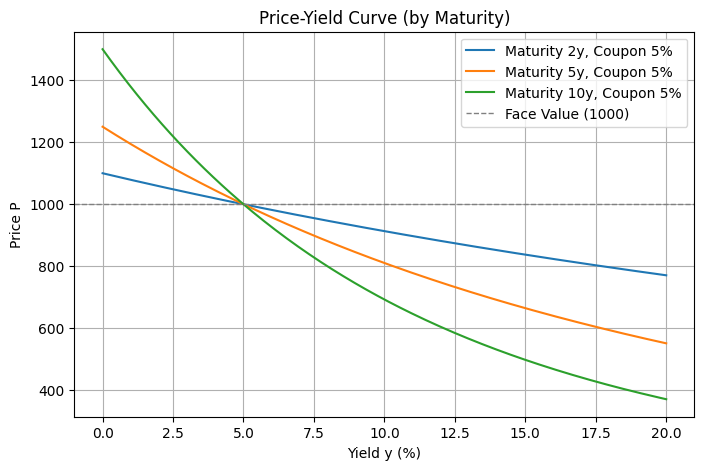

In [ ]:
import matplotlib.pyplot as plt


def plot_price_yield_curve(face_value, coupon_rate, maturity, frequency=1,
                            y_min=0.0, y_max=0.20, n_points=200):
    """
    価格–利回り曲線をプロットする

    横軸に利回り y、縦軸に価格 P をとり、
    金利と価格の逆相関・曲線の凸性を可視化する。
    （文字化け防止のため、グラフ内表記は英語にしている）
    """
    times, cfs = bond_cashflows(face_value, coupon_rate, maturity, frequency)

    yields = np.linspace(y_min, y_max, n_points)
    prices = np.array([price_from_yield(times, cfs, y, frequency) for y in yields])

    plt.plot(
        yields * 100, prices,
        label=f"Maturity {maturity}y, Coupon {coupon_rate*100:.0f}%"
    )

    return yields, prices


# ===== 実行部分 =====

plt.figure(figsize=(8, 5))

# 満期の異なる3本の債券で比較 → 満期が長いほど曲線が急になる（傾き・凸性が大きい）
for maturity in [2, 5, 10]:
    plot_price_yield_curve(face_value=1000, coupon_rate=0.05, maturity=maturity)

plt.axhline(1000, color="gray", linestyle="--", linewidth=1, label="Face Value (1000)")
plt.xlabel("Yield y (%)")
plt.ylabel("Price P")
plt.title("Price-Yield Curve (by Maturity)")
plt.grid(True)
plt.legend()
plt.show()

#2-5 デュレーション（Duration）

## デュレーションとは何か

2-4で見たように、金利 $r$ と債券価格 $P$ は逆方向に動く。

しかし、
> 金利が1%変化したとき、価格はどれくらい変わるのか？

という問いにはまだ答えていない。

この「金利変動に対する価格の感応度」を定量化する指標が、デュレーションである。

---

## マコーレー・デュレーション（Macaulay Duration）

債券の将来キャッシュフローが回収されるまでの「現在価値加重平均時間」。

$$
D_M = \frac{\sum_{t=1}^{N} t \cdot \dfrac{CF_t}{(1+y)^t}}{P}
$$

- $D_M$：マコーレー・デュレーション（単位：年）
- $P$：債券価格（2-2の価格式で計算される値）
- $y$：最終利回り（YTM）
- $CF_t$：時点 $t$ のキャッシュフロー

各期の現在価値 $\dfrac{CF_t}{(1+y)^t}$ を重みとして、時間 $t$ の加重平均を取ったもの。
早く受け取るキャッシュフローほど重みが大きく、遅いキャッシュフローほど重みが小さい。

※ ゼロクーポン債では満期時にのみキャッシュフローが存在するため、$D_M = N$（満期そのもの）。

---

## 修正デュレーション（Modified Duration）

マコーレー・デュレーションは「時間の平均」だったが、実務で重要なのは

> 金利が変化したとき、価格がどれだけ変動するか

である。この価格の金利感応度を表す指標が修正デュレーション。

$$
D_{mod} = -\frac{1}{P}\frac{dP}{dy} = \frac{D_M}{1+y}
$$

- マイナス符号は「金利と価格が逆方向に動く」ことを反映している。
- 離散複利の場合、マコーレー・デュレーションを $(1+y)$ で割るだけで得られる。

---

## DV01 / PV01（Dollar Value of 01）

金利が **1bp（0.01%＝0.0001）** 変化したときの価格変化額（絶対金額）。

$$
DV01 \approx P \times D_{mod} \times 0.0001
$$

- デュレーションが「％変化」を表すのに対し、DV01は「金額変化」を表す実務指標。
- 債券ポートフォリオのヘッジ計算などでよく使われる。

---

## 1次近似 vs 実際の価格変化

修正デュレーションを使うと、金利がわずかに $\Delta y$ 変化したときの価格変化率は次のように近似できる（1次のテイラー展開）。

$$
\frac{\Delta P}{P} \approx -D_{mod}\,\Delta y
$$

この近似は $\Delta y$ が小さいときは良い近似だが、$\Delta y$ が大きくなるほど、
実際の価格変化（曲線に沿った変化）とのズレが大きくなる。
この誤差は、価格–利回り曲線が直線ではなく凸であること（2-4参照）に起因する。
このズレを補正するのが2-6のコンベキシティである。

👉 デュレーションは「価格の金利感応度」を一次近似で表す指標である。

👉 近似が効くのは金利変化が小さいときに限られる。

---

## Python実装：duration各種

In [ ]:
def macaulay_duration(times, cashflows, y, frequency=1):
    """
    マコーレー・デュレーションを計算する

    times      : 各キャッシュフローの発生時点（年）
    cashflows  : 各時点のキャッシュフロー
    y          : 割引に用いる利回り（YTMなど）
    frequency  : 年間の複利回数
    """
    times = np.asarray(times, dtype=float)
    cashflows = np.asarray(cashflows, dtype=float)

    discount_factors = 1.0 / (1.0 + y / frequency) ** (times * frequency)
    pv_cfs = cashflows * discount_factors

    price = np.sum(pv_cfs)
    weighted_time = np.sum(times * pv_cfs)

    return weighted_time / price


def modified_duration(times, cashflows, y, frequency=1):
    """
    修正デュレーションを計算する（マコーレー・デュレーションから変換）
    """
    d_mac = macaulay_duration(times, cashflows, y, frequency)
    return d_mac / (1.0 + y / frequency)


def dv01(times, cashflows, y, frequency=1, bp=0.0001):
    """
    DV01（PV01）：金利が bp（デフォルト1bp=0.0001）変化したときの価格変化額

    実際に y±bp/2 で価格を計算し直す方法（数値微分に近い）で求める。
    """
    price_up = price_from_yield(times, cashflows, y + bp / 2, frequency)
    price_down = price_from_yield(times, cashflows, y - bp / 2, frequency)
    return abs(price_up - price_down)


# ===== 実行部分 =====

# 2-1のクーポン債（額面1000円、クーポン率10%、満期3年）を使う
times_coupon, cfs_coupon = bond_cashflows(face_value=1000, coupon_rate=0.10, maturity=3)
y = 0.04  # 割引に使う利回り

price = price_from_yield(times_coupon, cfs_coupon, y)
d_mac = macaulay_duration(times_coupon, cfs_coupon, y)
d_mod = modified_duration(times_coupon, cfs_coupon, y)
dv = dv01(times_coupon, cfs_coupon, y)

print(f"価格 P                       = {price:.4f}")
print(f"マコーレー・デュレーション D_M = {d_mac:.4f} 年")
print(f"修正デュレーション D_mod       = {d_mod:.4f}")
print(f"DV01（1bpあたりの価格変化額）   = {dv:.6f}")

print()

# ----- 1次近似 vs 実際の価格変化の検証 -----
print("Δy に対する 1次近似 vs 実際の価格変化")
for dy in [0.0001, 0.001, 0.01, 0.02, 0.05]:
    approx_change = -d_mod * dy * price          # 1次近似（金額ベース）
    actual_price = price_from_yield(times_coupon, cfs_coupon, y + dy)
    actual_change = actual_price - price          # 実際の価格変化

    print(f"  Δy={dy*100:5.2f}%  approx={approx_change:8.4f}  actual={actual_change:8.4f}  error={actual_change-approx_change:8.4f}")

価格 P                       = 1166.5055
マコーレー・デュレーション D_M = 2.7559 年
修正デュレーション D_mod       = 2.6499
DV01（1bpあたりの価格変化額）   = 0.309111

Δy に対する 1次近似 vs 実際の価格変化
  Δy= 0.01%  approx= -0.3091  actual= -0.3091  error=  0.0001
  Δy= 0.10%  approx= -3.0911  actual= -3.0853  error=  0.0058
  Δy= 1.00%  approx=-30.9111  actual=-30.3431  error=  0.5680
  Δy= 2.00%  approx=-61.8222  actual=-59.5850  error=  2.2372
  Δy= 5.00%  approx=-154.5554  actual=-141.1925  error= 13.3629


#2-6 コンベキシティ（Convexity）

## なぜコンベキシティが必要か

2-5の修正デュレーションによる近似は、あくまで**1次（直線）近似**だった。

$$
\frac{\Delta P}{P} \approx -D_{mod}\,\Delta y
$$

しかし2-4で見たように、価格–利回り曲線は直線ではなく**下に凸**な曲線である。
そのため、$\Delta y$ が大きくなるほど1次近似の誤差が大きくなる。

この誤差を補正するために、価格変化の**2次の項**（曲線の曲がり具合）を導入したものがコンベキシティである。

---

## コンベキシティの定義

$$
C = \frac{1}{P}\frac{d^2P}{dy^2}
$$

離散複利の場合、次のように書ける。

$$
C = \frac{1}{P}\sum_{t=1}^{N} \frac{t(t+1) \cdot CF_t}{(1+y)^{t+2}}
$$

- $C$：コンベキシティ
- $P$：債券価格
- $CF_t$：時点 $t$ のキャッシュフロー
- $y$：利回り

デュレーションが「1次微分（傾き）」を捉える指標であるのに対し、
コンベキシティは「2次微分（曲がり具合）」を捉える指標である。

---

## 2次近似（テイラー展開）

デュレーションとコンベキシティを組み合わせると、価格変化率のより精度の高い近似式が得られる。

$$
\frac{\Delta P}{P} \approx -D_{mod}\,\Delta y + \frac{1}{2}C\,(\Delta y)^2
$$

- 第1項（1次項）：デュレーションによる直線近似（2-5）
- 第2項（2次項）：コンベキシティによる曲線の補正

$\Delta y$ が正でも負でも第2項は必ず非負（$(\Delta y)^2 \ge 0$）となるため、
コンベキシティを加えると近似価格は必ず**上方修正**される。
これは「価格–利回り曲線が凸である」こと（2-4）と整合的である。

👉 コンベキシティは、デュレーションによる直線近似の「誤差」を補正する2次の項である。

👉 金利変化が大きいほど、コンベキシティの補正効果は大きくなる。

---

## Python実装：convexity、1次近似 vs 2次近似の比較

価格 P                 = 1486.6537
修正デュレーション D_mod = 7.0854
コンベキシティ C         = 66.4763

      Δy    1st-order    2nd-order       Actual
   -3.0%     316.0058     360.4780     365.7637
   -2.0%     210.6705     230.4360     231.9531
   -1.0%     105.3353     110.2766     110.4605
    1.0%    -105.3353    -100.3939    -100.5670
    2.0%    -210.6705    -190.9051    -192.2503
    3.0%    -316.0058    -271.5335    -275.9463


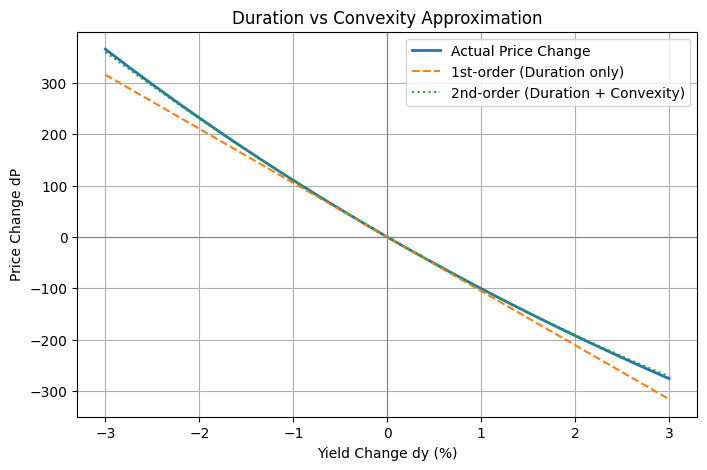

In [ ]:
def convexity(times, cashflows, y, frequency=1):
    """
    コンベキシティを計算する

    times      : 各キャッシュフローの発生時点（年）
    cashflows  : 各時点のキャッシュフロー
    y          : 割引に用いる利回り
    frequency  : 年間の複利回数
    """
    times = np.asarray(times, dtype=float)
    cashflows = np.asarray(cashflows, dtype=float)

    discount_factors = 1.0 / (1.0 + y / frequency) ** (times * frequency)
    price = np.sum(cashflows * discount_factors)

    # Σ t(t+1) * CF_t / (1+y)^(t+2)
    numerator = np.sum(
        times * (times + 1) * cashflows / (1.0 + y / frequency) ** (times * frequency + 2)
    )

    return numerator / price


# ===== 実行部分 =====

times_coupon, cfs_coupon = bond_cashflows(face_value=1000, coupon_rate=0.10, maturity=10)
y = 0.04

price = price_from_yield(times_coupon, cfs_coupon, y)
d_mod = modified_duration(times_coupon, cfs_coupon, y)
c = convexity(times_coupon, cfs_coupon, y)

print(f"価格 P                 = {price:.4f}")
print(f"修正デュレーション D_mod = {d_mod:.4f}")
print(f"コンベキシティ C         = {c:.4f}")
print()

# ----- 1次近似 vs 2次近似 vs 実際の価格変化 -----
print(f"{'Δy':>8} {'1st-order':>12} {'2nd-order':>12} {'Actual':>12}")
for dy in [-0.03, -0.02, -0.01, 0.01, 0.02, 0.03]:
    approx1 = -d_mod * dy * price
    approx2 = (-d_mod * dy + 0.5 * c * dy**2) * price
    actual = price_from_yield(times_coupon, cfs_coupon, y + dy) - price

    print(f"{dy*100:7.1f}% {approx1:12.4f} {approx2:12.4f} {actual:12.4f}")

# ----- 可視化：1次近似 vs 2次近似 vs 実際 -----
import matplotlib.pyplot as plt

dys = np.linspace(-0.03, 0.03, 100)
approx1_curve = [-d_mod * dy * price for dy in dys]
approx2_curve = [(-d_mod * dy + 0.5 * c * dy**2) * price for dy in dys]
actual_curve = [price_from_yield(times_coupon, cfs_coupon, y + dy) - price for dy in dys]

plt.figure(figsize=(8, 5))
plt.plot(dys * 100, actual_curve, label="Actual Price Change", linewidth=2)
plt.plot(dys * 100, approx1_curve, "--", label="1st-order (Duration only)")
plt.plot(dys * 100, approx2_curve, ":", label="2nd-order (Duration + Convexity)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Yield Change dy (%)")
plt.ylabel("Price Change dP")
plt.title("Duration vs Convexity Approximation")
plt.grid(True)
plt.legend()
plt.show()

#2-7 イールドカーブと期間構造（Term Structure）

## 2-2までの前提の限界

2-2の価格式では、割引に使う金利 $r$ が**全期間で一定（フラットレート）**という単純化を置いていた。

$$
P = \sum_{t=1}^{N} \frac{CF_t}{(1+r)^t}
$$

しかし実際の市場では、満期が異なれば金利水準も異なる。
1年物の金利と10年物の金利は一般に異なる値を取る。

満期ごとに異なる金利を「スポットレート（Spot Rate）」と呼び、
満期に対してスポットレートをプロットしたものを**イールドカーブ（Yield Curve）**と呼ぶ。

---

## スポットレート（Spot Rate）とフォワードレート（Forward Rate）

- **スポットレート $r_t$**：現時点から満期 $t$ までの割引に使う金利（「今から $t$ 年」の金利）。
- **フォワードレート $f_{t_1,t_2}$**：将来のある時点 $t_1$ から $t_2$ の間に適用されると市場が織り込んでいる金利。

無裁定の原則（3-1で詳しく扱う）より、スポットレートとフォワードレートの間には次の関係が成り立つ。

$$
(1+r_{t_2})^{t_2} = (1+r_{t_1})^{t_1}(1+f_{t_1,t_2})^{t_2-t_1}
$$

これを $f_{t_1,t_2}$ について解くと、

$$
f_{t_1,t_2} = \left(\frac{(1+r_{t_2})^{t_2}}{(1+r_{t_1})^{t_1}}\right)^{\frac{1}{t_2-t_1}} - 1
$$

---

## ブートストラップ法（Bootstrapping）

スポットレートは、市場で観測される「額面（パー）で発行された利付債の利回り（パー・イールド）」から、
満期の短いものから順に1本ずつ求めることができる。この手続きをブートストラップ法と呼ぶ。

考え方：
1. 満期1年の債券の価格式は $r_1$ だけを含むので、直接解ける。
2. 満期2年の債券の価格式には $r_1$（既知）と $r_2$（未知）が含まれるので、$r_2$ について解く。
3. これを満期の短い方から順に繰り返し、全期間のスポットレートを求める。

---

## 割引曲線と補間

スポットレート $r_t$ が分かれば、任意の時点 $t$ の割引因子は

$$
DF(t) = \frac{1}{(1+r_t)^t}
$$

で求まる。ブートストラップで得られるのは離散的な満期点でのスポットレートのみなので、
その中間の満期の割引率は**補間（Interpolation）**によって求める（ここでは単純な線形補間を使う）。

👉 イールドカーブは「満期ごとに異なる金利」を表現したものであり、2-2までのフラットレート仮定を一般化したもの。

👉 ブートストラップは「短い満期から順に、既知の情報を使って未知の金利を1本ずつ解く」という発想。

---

## Python実装：bootstrap_zero_curve, forward_rate

満期    パー・イールド   スポットレート
1年       2.000%          2.000%
2年       2.500%          2.506%
3年       2.800%          2.813%
4年       3.000%          3.020%
5年       3.100%          3.123%

2年後〜4年後のフォワードレート = 3.536%


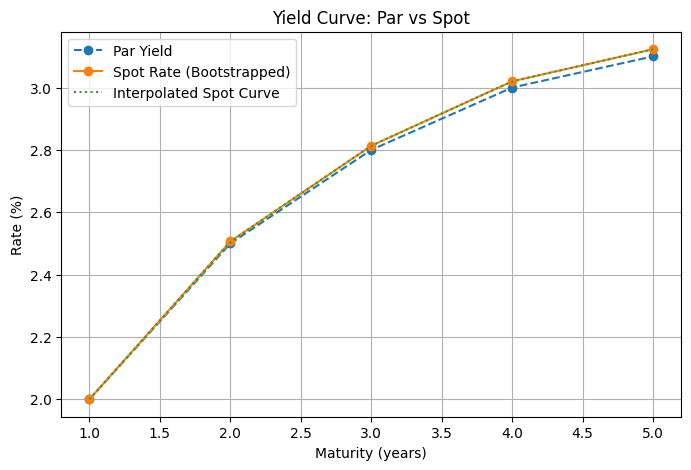

In [ ]:
def bootstrap_zero_curve(maturities, par_yields, face_value=100, frequency=1):
    """
    パー・イールド（額面発行の利付債の利回り）からスポットレート曲線をブートストラップする

    maturities  : 満期のリスト（年、昇順、例: [1, 2, 3, ...]）
    par_yields  : 各満期に対応するパー・イールド（クーポン率＝利回りとなる利率）
    face_value  : 額面（計算結果には影響しない、便宜上100とする）
    frequency   : 年間クーポン支払回数

    戻り値:
        spot_rates : 各満期に対応するスポットレートの配列（maturitiesと同じ順）
    """
    maturities = np.asarray(maturities, dtype=float)
    par_yields = np.asarray(par_yields, dtype=float)

    spot_rates = np.zeros(len(maturities))

    for i, (T, c) in enumerate(zip(maturities, par_yields)):
        # パー債なので、価格は額面に一致する（P = face_value）という条件を使う
        coupon = face_value * c / frequency
        n_periods = int(round(T * frequency))

        # 満期未満のクーポンは、既に求めたスポットレート（線形補間）で割り引く
        pv_known = 0.0
        for j in range(1, n_periods):
            t_j = j / frequency
            r_j = np.interp(t_j, maturities[:i + 1], spot_rates[:i + 1])
            pv_known += coupon / (1.0 + r_j) ** t_j

        # 最終期のみ未知の spot_rates[i] を含む → これについて解く
        # face_value = pv_known + (coupon + face_value) / (1 + r_T)^T
        remaining = face_value - pv_known
        last_cf = coupon + face_value

        spot_rates[i] = (last_cf / remaining) ** (1.0 / T) - 1.0

    return spot_rates


def forward_rate(maturities, spot_rates, t1, t2):
    """
    スポットレート曲線からフォワードレートを求める

    maturities, spot_rates : ブートストラップで得たスポットレート曲線
    t1, t2                 : フォワードレートを求める期間（t1 < t2）
    """
    r1 = np.interp(t1, maturities, spot_rates)
    r2 = np.interp(t2, maturities, spot_rates)

    return ((1 + r2) ** t2 / (1 + r1) ** t1) ** (1.0 / (t2 - t1)) - 1.0


# ===== 実行部分 =====

# 満期1〜5年のパー・イールド（市場で観測された利回りと仮定）
maturities = [1, 2, 3, 4, 5]
par_yields = [0.020, 0.025, 0.028, 0.030, 0.031]

spot_rates = bootstrap_zero_curve(maturities, par_yields)

print("満期    パー・イールド   スポットレート")
for T, py, r in zip(maturities, par_yields, spot_rates):
    print(f"{T}年      {py*100:6.3f}%         {r*100:6.3f}%")

print()

# 2年後から4年後にかけてのフォワードレート
f_2_4 = forward_rate(maturities, spot_rates, 2, 4)
print(f"2年後〜4年後のフォワードレート = {f_2_4*100:.3f}%")

# ----- 可視化 -----
import matplotlib.pyplot as plt

fine_maturities = np.linspace(1, 5, 50)
interpolated_curve = np.interp(fine_maturities, maturities, spot_rates)

plt.figure(figsize=(8, 5))
plt.plot(maturities, np.array(par_yields) * 100, "o--", label="Par Yield")
plt.plot(maturities, spot_rates * 100, "o-", label="Spot Rate (Bootstrapped)")
plt.plot(fine_maturities, interpolated_curve * 100, ":", label="Interpolated Spot Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Rate (%)")
plt.title("Yield Curve: Par vs Spot")
plt.grid(True)
plt.legend()
plt.show()

#2-8 信用リスクとスプレッド（Credit Risk & Spread）

## デフォルトリスク（Default Risk）

- 発行体（企業や政府）が、約束したクーポンや元本を支払えなくなるリスク。
- 国債（信用力の高い発行体）はデフォルトリスクがほぼゼロと見なされることが多く、
  「無リスク金利（risk-free rate）」の基準として扱われる。
- 社債など信用力の低い発行体は、その分だけ高い利回りを要求される。

---

## 信用スプレッド（Credit Spread）

同じ満期の国債利回りと社債利回りの差を、信用スプレッド（クレジット・スプレッド）と呼ぶ。

$$
s = y_{\text{社債}} - y_{\text{国債}}
$$

- $s$：信用スプレッド
- $y_{\text{社債}}$：社債の利回り
- $y_{\text{国債}}$：同満期の国債（無リスク）利回り

信用力が低い発行体ほど、デフォルトの可能性を補償するために $s$ は大きくなる。

---

## スプレッド付き割引（Spread-Adjusted Discounting）

2-7で作った無リスクのスポットレート曲線 $r_t$ に、信用スプレッド $s$ を上乗せして割り引くことで、
信用リスクのある債券の価格を評価できる。

$$
P = \sum_{t=1}^{N} \frac{CF_t}{(1+r_t+s)^t}
$$

- 無リスク金利 $r_t$（2-7でブートストラップしたスポットレート）に、
  発行体固有の信用スプレッド $s$ を加えた割引率で現在価値を計算する。
- $s$ が大きいほど、割引率が高くなり、価格は下がる。

※ ここでは簡単のため、スプレッド $s$ は満期によらず一定（フラット）と仮定している。
　実際にはスプレッドにも期間構造（CDSカーブなど）が存在するが、ここでは扱わない。

👉 信用リスクは「割引率に上乗せするスプレッド」として、価格式にそのまま組み込める。

👉 スプレッドが大きいほど価格は低く、利回りは高くなる。

---

## Python実装：スプレッド付き価格計算（概念確認）

In [ ]:
def price_with_spread(times, cashflows, spot_maturities, spot_rates, spread):
    """
    無リスクのスポットレート曲線にスプレッドを上乗せして、信用リスクのある
    債券の価格を計算する

    times            : 評価対象債券のキャッシュフロー発生時点
    cashflows        : 評価対象債券のキャッシュフロー
    spot_maturities  : スポットレート曲線の満期（2-7のbootstrap結果）
    spot_rates       : スポットレート曲線のレート（2-7のbootstrap結果）
    spread           : 信用スプレッド（満期によらず一定と仮定）
    """
    times = np.asarray(times, dtype=float)
    cashflows = np.asarray(cashflows, dtype=float)

    # 各キャッシュフロー時点の無リスクスポットレートを補間で求める
    r_t = np.interp(times, spot_maturities, spot_rates)

    discount_factors = 1.0 / (1.0 + r_t + spread) ** times
    return np.sum(cashflows * discount_factors)


# ===== 実行部分 =====

# 2-7で求めたスポットレート曲線を再利用
maturities = [1, 2, 3, 4, 5]
par_yields = [0.020, 0.025, 0.028, 0.030, 0.031]
spot_rates = bootstrap_zero_curve(maturities, par_yields)

# 評価対象：額面1000円、クーポン率5%、満期5年の社債
times_corp, cfs_corp = bond_cashflows(face_value=1000, coupon_rate=0.05, maturity=5)

# 信用スプレッドを変えて、価格への影響を確認
print(f"{'スプレッド':>10} {'価格':>12}")
for spread in [0.000, 0.005, 0.010, 0.020, 0.050]:
    price = price_with_spread(times_corp, cfs_corp, maturities, spot_rates, spread)
    print(f"{spread*100:8.2f}%   {price:12.4f}")

     スプレッド           価格
    0.00%      1087.3526
    0.50%      1063.6233
    1.00%      1040.5499
    2.00%       996.2863
    5.00%       877.1706


#2-9 統合「債券評価シミュレーター」

## これまでの実装の統合

2-1〜2-6で作った関数（bond_cashflows, price_from_yield, ytm_from_price,
macaulay_duration, modified_duration, convexity）を、
1つの `Bond` クラスにまとめる。

クラス化することで、
- 債券の情報（額面・クーポン率・満期）を1つのオブジェクトとして保持できる
- 価格・YTM・デュレーション・コンベキシティを、そのオブジェクトのメソッドとして呼び出せる
- ipywidgets を使えば、パラメータをスライダーで動かしながら
  リアルタイムに価格が変わる様子を確認できる「電卓」が作れる

---

## Bondクラスの設計

| メソッド | 内容 | 対応節 |
|---------|------|--------|
| `price(y)` | 利回り $y$ における価格 | 2-2 |
| `ytm(price)` | 価格から利回りを逆算 | 2-3 |
| `macaulay_duration(y)` | マコーレー・デュレーション | 2-5 |
| `modified_duration(y)` | 修正デュレーション | 2-5 |
| `convexity(y)` | コンベキシティ | 2-6 |

👉 これは新しい理論の追加ではなく、これまでの関数群を「1つの債券」という単位でまとめ直しただけである。

---

## Python実装：Bondクラス ＋ ipywidgets電卓

#2-10 株式と債券の違い

これまで見てきた債券の性質を、株式と比較して整理する。

| 項目 | 株式（Stocks） | 債券（Bonds） |
|---|---|---|
| 性質 | 企業の所有権 | 政府・企業への貸付（負債証券） |
| 投資家の権利 | 議決権あり | 議決権なし |
| 収益の形 | 配当（不確実）＋値上がり益 | 利息（クーポン）または割引差益 |
| 元本返済 | なし | 満期時に元本返済 |
| キャッシュフロー | 不確実 | 比較的確実（デフォルト除く） |
| リスク水準 | 一般に高い | 一般に株式より低い（信用リスクに依存） |
| 価格特性 | 業績・成長期待・金利に依存 | 市場金利・信用リスクに依存 |
| 一般的評価 | ハイリスク・ハイリターン | ローリスク・安定収益（傾向） |

👉 債券は「あらかじめ決まったキャッシュフロー」を約束する契約であるのに対し、
株式は「企業の将来の成果に対する持分」である、という点が本質的な違い。

👉 この違いが、2-1〜2-9で見てきた「割引率・利回り・デュレーション・信用スプレッド」
といった債券特有の分析フレームワークの背景にある。